<a href="https://colab.research.google.com/github/JustusAkuku/Codveda-Technologies-Internship/blob/main/House_prices_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Loading and Inspection

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

# Define column names for the Boston Housing dataset
column_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
    'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]

# Load dataset, assuming it's space-separated and has no header
df = pd.read_csv('/content/drive/My Drive/house Prediction Data Set.csv', sep=r"\s+", header=None, names=column_names)
print("Dataset loaded successfully")
print("Shape:", df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully
Shape: (506, 14)


In [7]:
# How many rows and columns?
print("Shape:", df.shape)

#Column names
print("\nColumns:", df.columns.to_list())

# Data types
print("\nData Types:\n", df.dtypes)

# First 5 rows
print("\nFirst 5 rows:")
df.head()

Shape: (506, 14)

Columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

Data Types:
 CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

First 5 rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [8]:
#Summary Statistics
print("\nSummary Statistics:")
df.describe()


Summary Statistics:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [9]:
# Missing Values( No missing and duplicate values in this dataset)
print("\nMissing Values:",df.isnull().sum())

#Duplicates
print("\nDuplicates:",df.duplicated().sum())


Missing Values: CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Duplicates: 0


### Distribution of the Target Variable (MEDV)

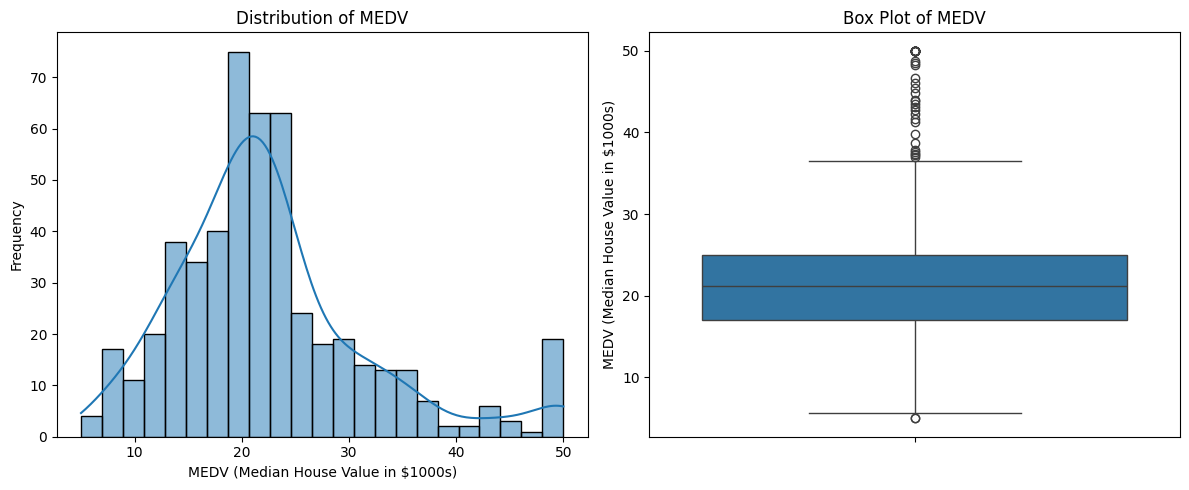

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['MEDV'], kde=True)
plt.title('Distribution of MEDV')
plt.xlabel('MEDV (Median House Value in $1000s)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['MEDV'])
plt.title('Box Plot of MEDV')
plt.ylabel('MEDV (Median House Value in $1000s)')

plt.tight_layout()
plt.show()

### Correlation Analysis and Scatter Plots with MEDV

Correlation of features with MEDV:
 MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64

Top 5 features highly correlated with MEDV: ['RM', 'ZN', 'B', 'DIS', 'CHAS']


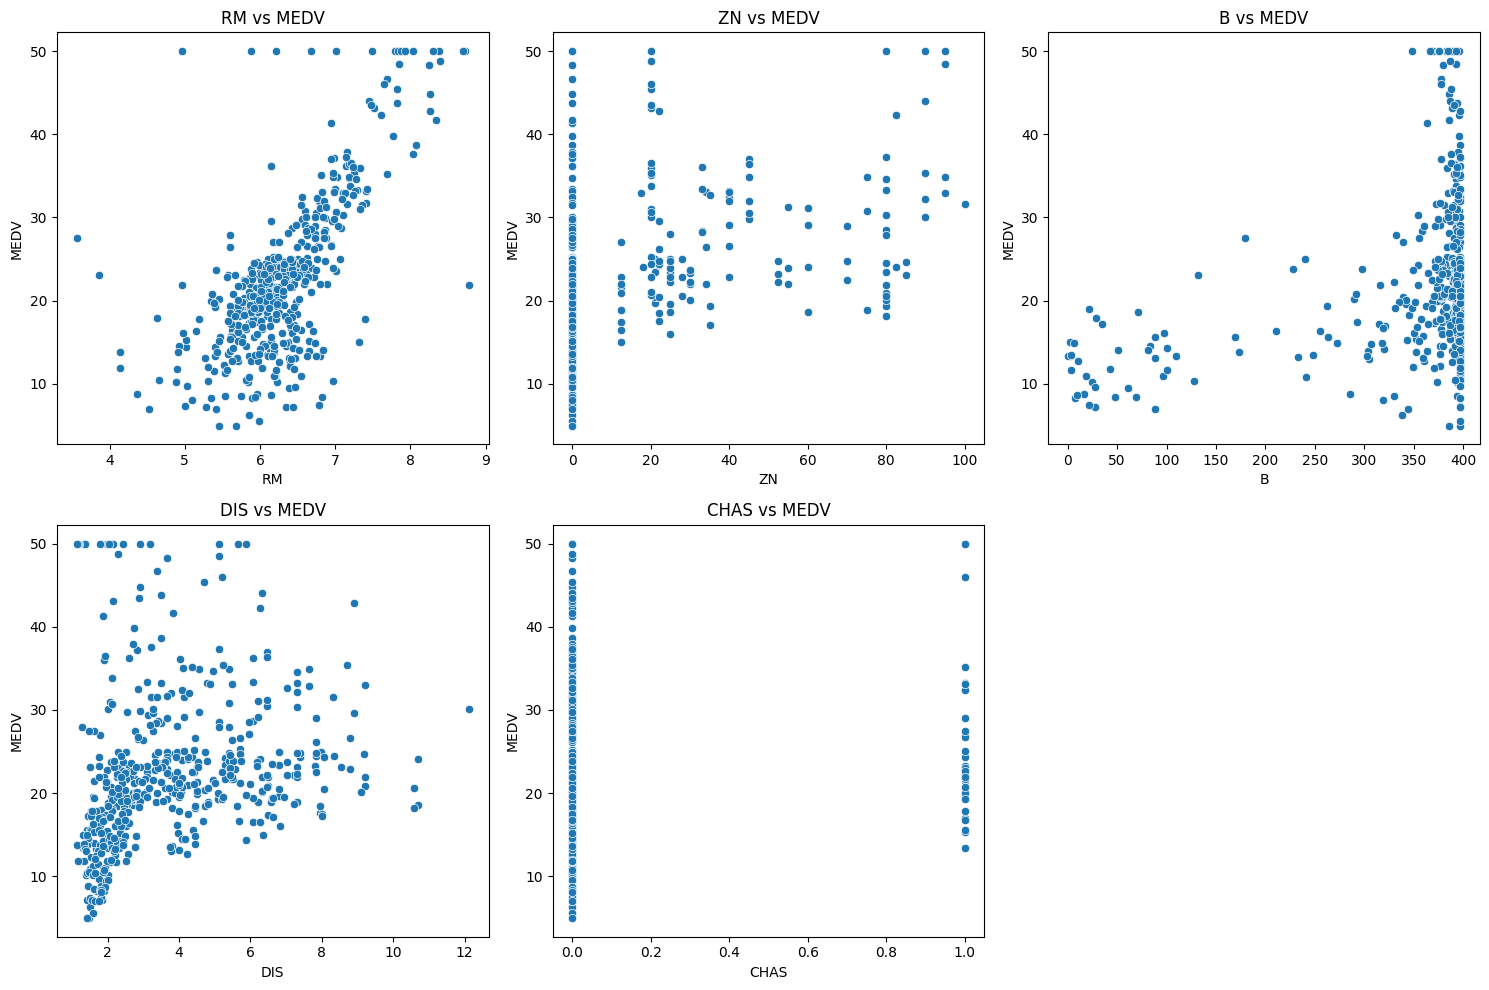

In [12]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Get correlations with MEDV
medv_correlation = correlation_matrix['MEDV'].sort_values(ascending=False)
print("Correlation of features with MEDV:\n", medv_correlation)

# Select top N features (e.g., top 5) highly correlated with MEDV
# Exclude MEDV itself from the list of features to plot against
top_correlated_features = medv_correlation[1:6].index.to_list() # Get top 5 excluding MEDV

print(f"\nTop 5 features highly correlated with MEDV: {top_correlated_features}")

# Create scatter plots for selected features against MEDV
plt.figure(figsize=(15, 10))
for i, feature in enumerate(top_correlated_features):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of features
    sns.scatterplot(x=df[feature], y=df['MEDV'])
    plt.title(f'{feature} vs MEDV')
    plt.xlabel(feature)
    plt.ylabel('MEDV')
plt.tight_layout()
plt.show()

##House Prices Prediction Model Building

### Data Splitting

In [13]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('MEDV', axis=1)  # All columns except 'MEDV' are features
y = df['MEDV']              # 'MEDV' is the target variable

# Split the data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing
# random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (404, 13)
X_test shape: (102, 13)
y_train shape: (404,)
y_test shape: (102,)


### Linear Regression Model Training

In [14]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Model Evaluation

Mean Squared Error (MSE): 24.29
R-squared (R2): 0.67


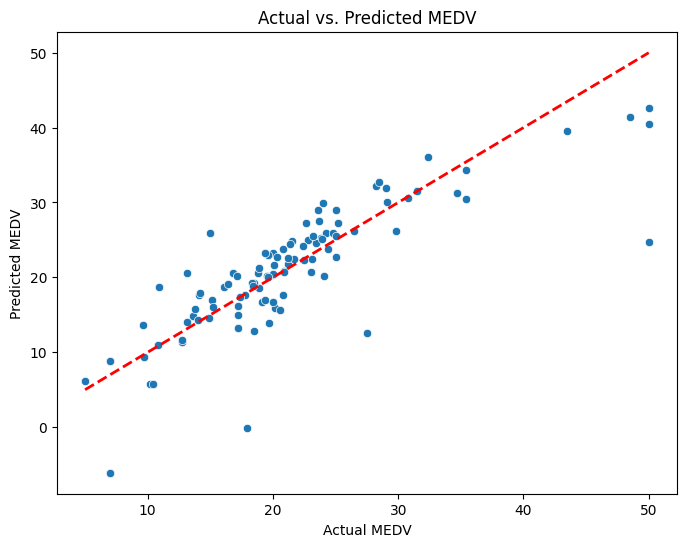

In [15]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize predictions vs actual values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs. Predicted MEDV")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.show()

In [16]:
print("First 5 predicted values (y_pred):")
print(y_pred[:5])

First 5 predicted values (y_pred):
[28.99672362 36.02556534 14.81694405 25.03197915 18.76987992]


### Feature Importance based on Linear Regression Coefficients

Feature Importances (sorted by absolute coefficient magnitude):

    Feature  Coefficient
4       NOX   -17.202633
5        RM     4.438835
3      CHAS     2.784438
7       DIS    -1.447865
10  PTRATIO    -0.915456
12    LSTAT    -0.508571
8       RAD     0.262430
0      CRIM    -0.113056
2     INDUS     0.040381
1        ZN     0.030110
11        B     0.012351
9       TAX    -0.010647
6       AGE    -0.006296


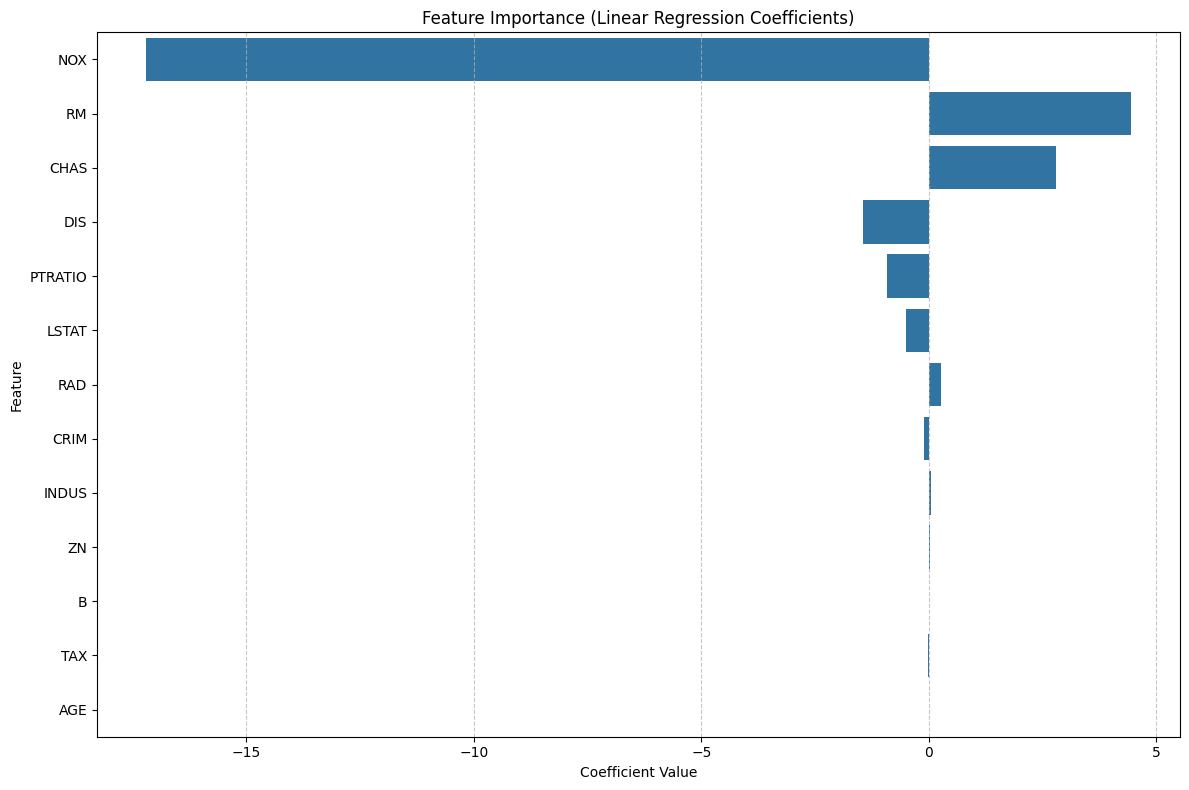

In [17]:
# Get feature names from the training data
feature_names = X_train.columns

# Get the coefficients from the trained model
coefficients = model.coef_

# Create a DataFrame to easily view and sort feature importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by the absolute value of coefficients for better visualization of importance
feature_importance_df['Abs_Coefficient'] = np.abs(feature_importance_df['Coefficient'])
feature_importance_df = feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Feature Importances (sorted by absolute coefficient magnitude):\n")
print(feature_importance_df[['Feature', 'Coefficient']])

# Plotting feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df)
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Model Comparison: Linear Regression vs. Other Algorithms

Comparison on the performance of different models to find the best fit for the house prediction Dataset.

### Decision Tree Regressor

In [19]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree Regressor model trained successfully.")

Decision Tree Regressor model trained successfully.


Decision Tree - Mean Squared Error (MSE): 10.42
Decision Tree - R-squared (R2): 0.86


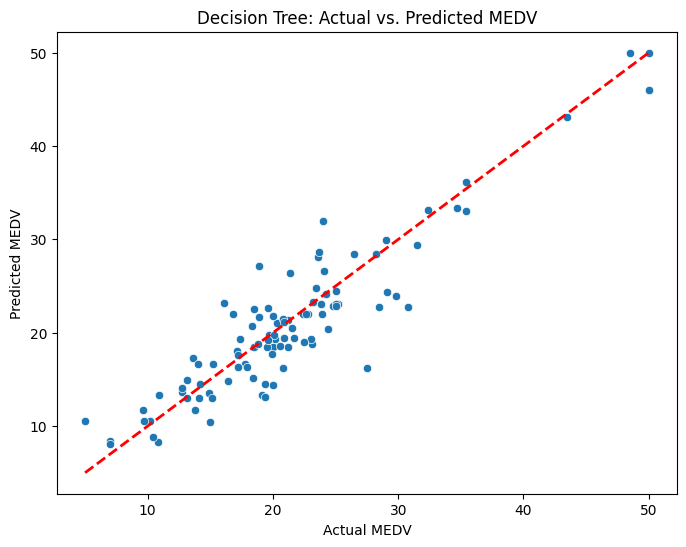

In [20]:
# Make predictions on the test set using Decision Tree
y_pred_dt = dt_model.predict(X_test)

# Calculate Mean Squared Error for Decision Tree
mse_dt = mean_squared_error(y_test, y_pred_dt)

# Calculate R-squared for Decision Tree
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree - Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"Decision Tree - R-squared (R2): {r2_dt:.2f}")

# Visualize predictions vs actual values for Decision Tree
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_dt)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Decision Tree: Actual vs. Predicted MEDV")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.show()

In [21]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


Random Forest - Mean Squared Error (MSE): 7.90
Random Forest - R-squared (R2): 0.89


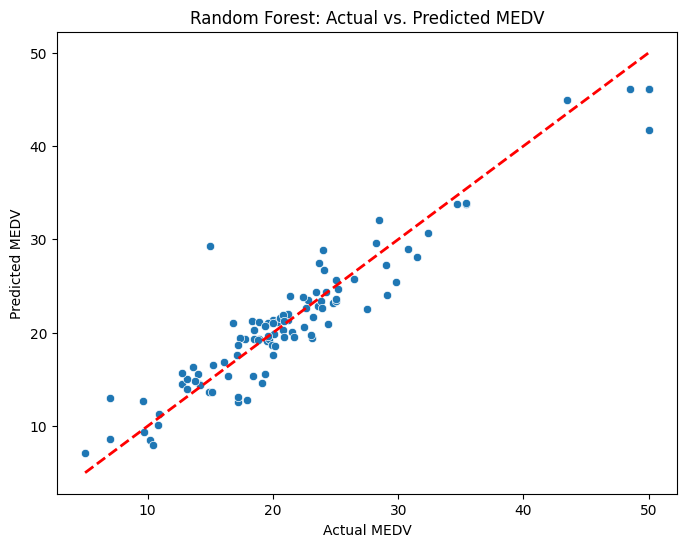

In [22]:
# Make predictions on the test set using Random Forest
y_pred_rf = rf_model.predict(X_test)

# Calculate Mean Squared Error for Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)

# Calculate R-squared for Random Forest
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest - R-squared (R2): {r2_rf:.2f}")

# Visualize predictions vs actual values for Random Forest
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Random Forest: Actual vs. Predicted MEDV")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.show()

### Comprehensive Model Comparison

In [23]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree Regressor', 'Random Forest Regressor'],
    'Mean Squared Error (MSE)': [mse, mse_dt, mse_rf],
    'R-squared (R2)': [r2, r2_dt, r2_rf]
})

# Sort by R-squared in descending order to see the best performing model first
model_comparison = model_comparison.sort_values(by='R-squared (R2)', ascending=False).reset_index(drop=True)

display(model_comparison)

print("\nBased on the R-squared values, the Random Forest Regressor appears to be the best performing model among the three for this dataset, as it has the highest R-squared and the lowest Mean Squared Error.")

,Model,Mean Squared Error (MSE),R-squared (R2)
0,Random Forest Regressor,7.901514,0.892253
1,Decision Tree Regressor,10.416078,0.857963
2,Linear Regression,24.291119,0.668759



Based on the R-squared values, the Random Forest Regressor appears to be the best performing model among the three for this dataset, as it has the highest R-squared and the lowest Mean Squared Error.
